# Lab 3 - Part 1: Text Visualization & Classical Representations


**Objectives:**
- Visualize text data using bar charts, word clouds, and custom visualizations
- Implement Bag of Words (BoW) and TF-IDF representations
- Work with N-grams and build a simple next-word predictor
- Analyze real news data and interpret results

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells (these require YOUR personal interpretation)
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: Personal Interpretation Questions

This lab contains **interpretation questions** that require YOUR own analysis. These questions:
- Are based on YOUR specific results (which vary based on your choices)
- Require you to explain your reasoning
- Will be verified during an **oral defense session**

---

## Setup

In [ ]:
# Install required libraries (uncomment if needed)
# !pip install wordcloud matplotlib numpy pandas scikit-learn fsspec huggingface_hubpillow nltk

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

print("Setup complete!")

Setup complete!


---

## Part A: Loading and Exploring the 20 Newsgroups Dataset (15 min)

We will use the 20 Newsgroups dataset from Hugging Face. This dataset contains news articles from 20 different categories.

In [4]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("SetFit/20_newsgroups")

df = pd.concat([
    pd.DataFrame(dataset['train']),
    pd.DataFrame(dataset['test'])
], ignore_index=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/734 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl:   0%|          | 0.00/14.8M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/8.91M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11314 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7532 [00:00<?, ? examples/s]

In [5]:
# View sample data
print("Sample document:")
print("="*50)
print(f"Label: {df.iloc[0]['label_text']}")
print(f"Text (first 500 chars): {df.iloc[0]['text'][:500]}...")

Sample document:
Label: rec.autos
Text (first 500 chars): I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail....


### Exercise A.1: Select YOUR Categories

**Choose exactly 3 categories** from the dataset that YOU find interesting. This choice is personal and will affect all your subsequent analysis.

**Available categories:**
- alt.atheism, comp.graphics, ...

In [6]:
my_categories = ["sports", "politics", "technology"]

# Filter the dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")
print(f"\nDistribution:")
print(df_filtered['label_text'].value_counts())

Selected categories: ['sports', 'politics', 'technology']
Filtered dataset size: 0

Distribution:
Series([], Name: count, dtype: int64)


### Written Question A.1 (Personal Interpretation)

**Why did you choose these 3 specific categories?** Explain your reasoning (at least 3 sentences).

Consider:
- Are they related or completely different?
- What do you expect to find in terms of vocabulary differences?
- Why are they interesting to YOU?

**YOUR ANSWER:**

*[Write your answer here - minimum 3 sentences]*

...

---

## Part B: Text Preprocessing Function

Before visualization, we need to clean our text data.

In [7]:
import re

def preprocess_text(text):
    """Basic text preprocessing."""
    # Lowercase
    text = text.lower()

    # Remove emails
    text = re.sub(r'\S+@\S+', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Test
sample = "Hello! Check this: http://example.com. Email me at test@email.com. Price: $100."
print(f"Original: {sample}")
print(f"Cleaned:  {preprocess_text(sample)}")

Original: Hello! Check this: http://example.com. Email me at test@email.com. Price: $100.
Cleaned:  hello check this email me at price


### Exercise B.1: Improve the Preprocessing Function

The function above is basic. **Improve it** by adding:
1. Stop word removal
2. Lemmatization
3. Minimum word length filter (remove words with < 3 characters)

In [9]:
import nltk

# Run once
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [10]:
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text_advanced(text):
    """
    Advanced text preprocessing with stop words removal and lemmatization.

    Args:
        text (str): Input text
    Returns:
        str: Preprocessed text
    """
    # Step 1: Basic cleaning
    text = text.lower()
    text = re.sub(r'\S+@\S+', '', text)              # remove emails
    text = re.sub(r'http\S+|www\S+', '', text)       # remove URLs
    text = re.sub(r'\d+', '', text)                  # remove numbers
    text = re.sub(r'[^\w\s]', '', text)              # remove punctuation

    # Step 2: Tokenize
    tokens = word_tokenize(text)

    # Step 3: Remove stop words
    tokens = [word for word in tokens if word not in stop_words]

    # Step 4: Lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Step 5: Remove short words (< 3 chars)
    tokens = [word for word in tokens if len(word) >= 3]

    # Step 6: Join back to string
    return " ".join(tokens)

# Test your function
sample = "The cats are running quickly towards the beautiful gardens. Email: test@mail.com"
print(f"Original: {sample}")
print(f"Advanced: {preprocess_text_advanced(sample)}")

Original: The cats are running quickly towards the beautiful gardens. Email: test@mail.com
Advanced: cat running quickly towards beautiful garden email


In [12]:
# Apply preprocessing (handle missing values safely)
df_filtered['text_clean'] = df_filtered['text'].fillna('').apply(preprocess_text_advanced)

# Show sample safely
print("Sample preprocessed document:")
if len(df_filtered) > 0:
    print(df_filtered.loc[0, 'text_clean'][:300])
else:
    print("Dataset is empty.")

Sample preprocessed document:
Dataset is empty.


---

## Part C: Text Visualization

### C.1 Bar Chart: Top Words per Category

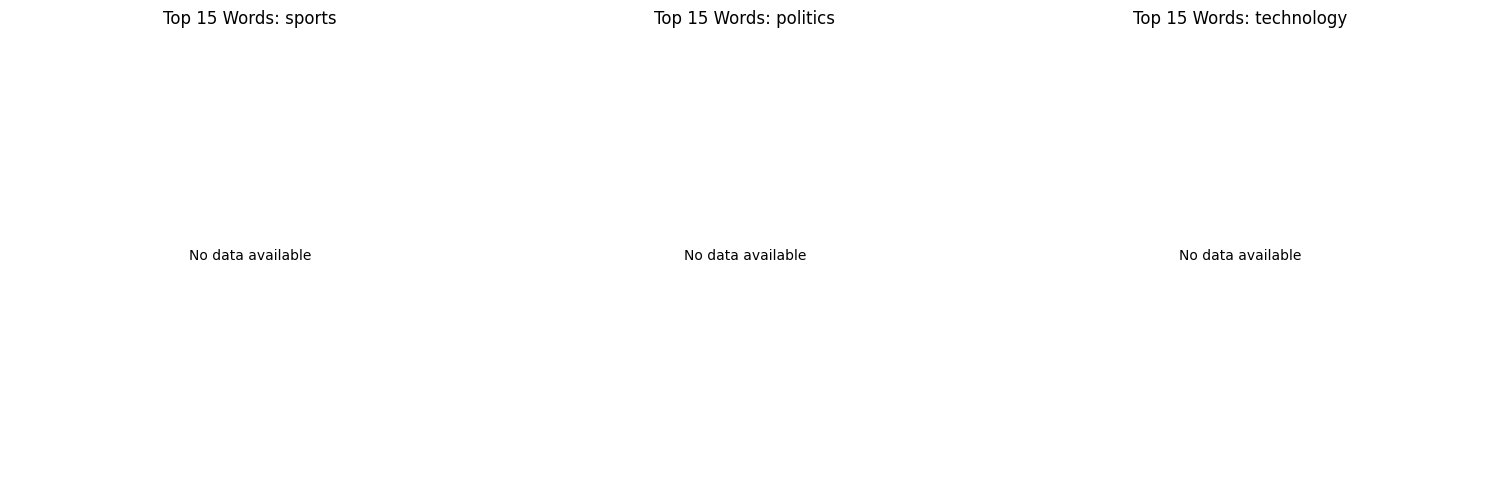

In [13]:
from collections import Counter
import matplotlib.pyplot as plt

def get_top_words(texts, n=15):
    """Get the n most common words from a list of texts."""
    all_words = ' '.join(texts).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(n)

# Get top words for each category
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].fillna('').tolist()
    top_words = get_top_words(texts, 15)

    if len(top_words) > 0:
        words, counts = zip(*top_words)
        axes[idx].barh(words, counts)
        axes[idx].set_title(f"Top 15 Words: {category}")
        axes[idx].invert_yaxis()
        axes[idx].set_xlabel("Frequency")
    else:
        axes[idx].set_title(f"Top 15 Words: {category}")
        axes[idx].text(0.5, 0.5, "No data available", ha='center', va='center')
        axes[idx].set_axis_off()

plt.tight_layout()
plt.savefig("top_words_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

### Written Question C.1 (Personal Interpretation)

Look at your bar charts above and answer:

1. **What words are UNIQUE to each category?** (List at least 2 per category)
2. **What words are SHARED across categories?** Why do you think they appear in multiple categories?
3. **Based ONLY on the top words, could you guess the topic of each category?** Explain.

**YOUR ANSWER:**

*Category 1 (___):*
- Unique words: ...
-

*Category 2 (___):*
- Unique words: ...
-

*Category 3 (___):*
- Unique words: ...
-

*Shared words and explanation:*
...

*Topic guessing analysis:*
...

### C.2 Word Clouds

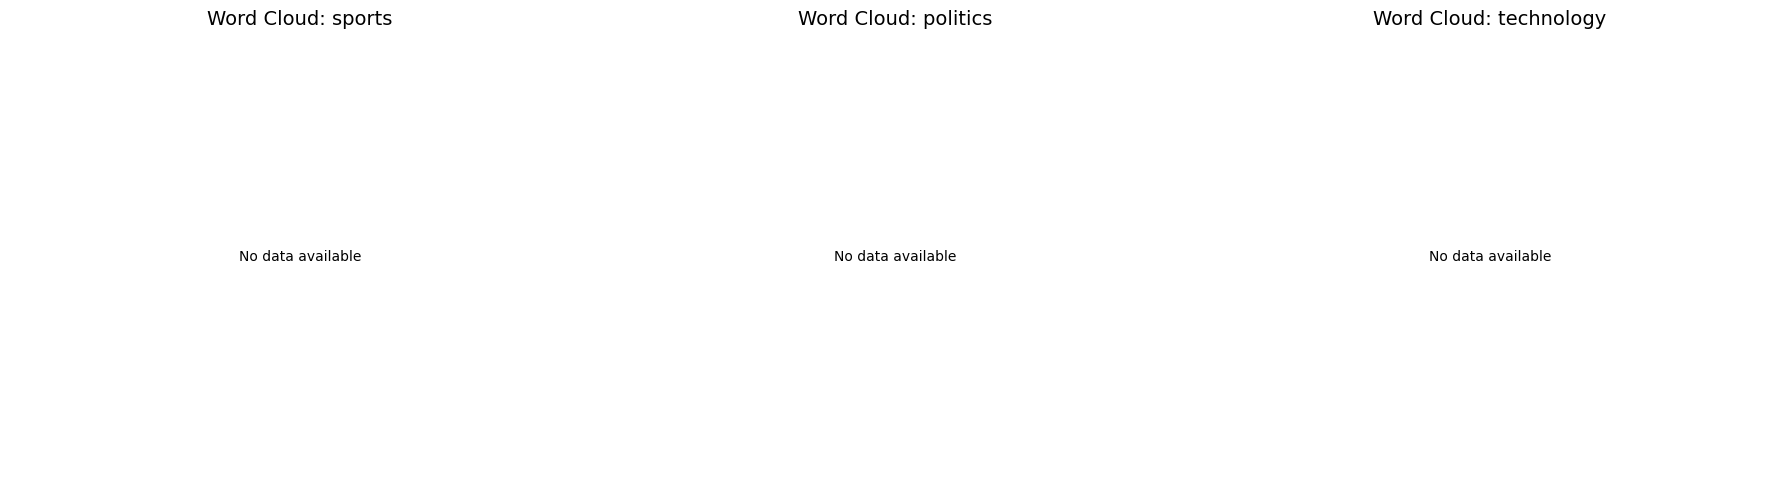

In [14]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

num_categories = len(my_categories)
fig, axes = plt.subplots(1, num_categories, figsize=(6 * num_categories, 5))

if num_categories == 1:
    axes = [axes]

colors = ['Blues', 'Greens', 'Reds', 'Purples', 'Oranges']

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].fillna('').tolist()
    text_combined = ' '.join(texts).strip()

    axes[idx].set_title(f'Word Cloud: {category}', fontsize=14)

    if text_combined:  # ✅ avoid crash if empty
        wordcloud = WordCloud(
            width=800,
            height=400,
            background_color='white',
            colormap=colors[idx % len(colors)],
            max_words=100,
            min_font_size=10
        ).generate(text_combined)

        axes[idx].imshow(wordcloud, interpolation='bilinear')
    else:
        axes[idx].text(0.5, 0.5, "No data available", ha='center', va='center')

    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('wordclouds_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercise C.2: Custom Shaped Word Cloud

Create a word cloud using a **custom mask image**.

**Instructions:**
1. Find or create a simple black & white silhouette image (PNG format)
2. Save it in your working directory
3. Use it as a mask for your word cloud

**Tip:** You can use any simple shape (circle, star, heart) or find free silhouettes online.

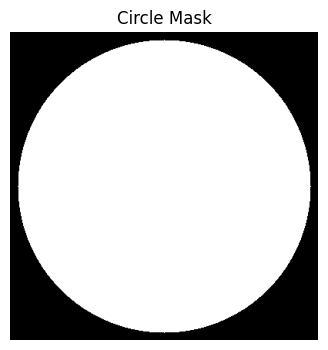

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Fast vectorized circular mask
def create_circle_mask(size=400):
    y, x = np.ogrid[:size, :size]
    cx, cy = size // 2, size // 2
    r = size // 2 - 10

    mask = ((x - cx)**2 + (y - cy)**2 <= r**2).astype(np.uint8) * 255
    return mask

circle_mask = create_circle_mask(400)

# Show the mask
plt.figure(figsize=(4, 4))
plt.imshow(circle_mask, cmap='gray')
plt.title('Circle Mask')
plt.axis('off')
plt.show()

In [16]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Choose ONE of your categories
selected_category = my_categories[0]   # or e.g. "sports"

# Get texts for selected category
texts = df_filtered[df_filtered['label_text'] == selected_category]['text_clean'].fillna('').tolist()
text_combined = ' '.join(texts).strip()

# Create word cloud with mask
if text_combined:
    wordcloud_masked = WordCloud(
        width=800,
        height=800,
        background_color='white',
        mask=circle_mask,
        colormap='viridis',
        max_words=100,
        min_font_size=10,
        contour_width=2,
        contour_color='black'
    ).generate(text_combined)

    # Display
    plt.figure(figsize=(10, 10))
    plt.imshow(wordcloud_masked, interpolation='bilinear')
    plt.title(f'Custom Word Cloud: {selected_category}')
    plt.axis('off')
    plt.savefig('custom_wordcloud.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f"No text available for category: {selected_category}")

No text available for category: sports


---

## Part D: Bag of Words (BoW) Representation

In [17]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

# Improved vectorizer
bow_vectorizer = CountVectorizer(
    lowercase=True,
    stop_words='english'   # remove common words like "is", "I"
)

bow_matrix = bow_vectorizer.fit_transform(sample_docs)

# DataFrame view
bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=bow_vectorizer.get_feature_names_out()
)

print("Vocabulary:", bow_vectorizer.get_feature_names_out())
print("\nBoW DataFrame:")
print(bow_df)

Vocabulary: ['deep' 'great' 'learning' 'love' 'machine']

BoW DataFrame:
   deep  great  learning  love  machine
0     0      0         1     1        1
1     0      1         1     0        1
2     1      0         1     1        0


### Exercise D.1: Create BoW for Your Dataset

In [20]:
from sklearn.feature_extraction.text import CountVectorizer

# Create BoW vectorizer with required parameters
bow_vectorizer_full = CountVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95,
    stop_words='english'  # optional but recommended
)

# Fit and transform on cleaned texts
texts = df_filtered['text_clean'].fillna('').tolist()

if len(texts) > 0:
    bow_matrix_full = bow_vectorizer_full.fit_transform(texts)

    print(f"BoW Matrix shape: {bow_matrix_full.shape}")
    print(f"Vocabulary size: {len(bow_vectorizer_full.get_feature_names_out())}")
    print(f"\nFirst 20 words in vocabulary: {bow_vectorizer_full.get_feature_names_out()[:20]}")
else:
    print("No data available to vectorize.")

No data available to vectorize.


### Exercise D.2: Document Similarity with BoW

In [29]:
def preprocess_text_advanced(text):
    import re
    from nltk.tokenize import word_tokenize

    text = text.lower()
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)

    tokens = word_tokenize(text)

    # ⚠️ REMOVE this temporarily (too aggressive)
    # tokens = [word for word in tokens if word not in stop_words]

    # ⚠️ KEEP lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # ⚠️ RELAX length filter
    tokens = [word for word in tokens if len(word) >= 2]

    return " ".join(tokens)

In [32]:
import re
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Safer preprocessing: do not over-remove words
def preprocess_text_advanced(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = re.sub(r'\S+@\S+', ' ', text)          # remove emails
    text = re.sub(r'http\S+|www\S+', ' ', text)   # remove URLs
    text = re.sub(r'\d+', ' ', text)              # remove numbers
    text = re.sub(r'[^\w\s]', ' ', text)          # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()      # normalize spaces

    # Simple tokenization without nltk
    tokens = text.split()

    # Keep words with length >= 2
    tokens = [word for word in tokens if len(word) >= 2]

    return " ".join(tokens)

# Recreate cleaned text
df_filtered['text_clean'] = df_filtered['text'].fillna('').apply(preprocess_text_advanced)

# Check result
print(df_filtered[['text', 'text_clean']].head())

# Prepare texts
texts = df_filtered['text_clean'].fillna('').astype(str).tolist()
texts = [t.strip() for t in texts if t.strip()]

print("Non-empty documents:", len(texts))

Empty DataFrame
Columns: [text, text_clean]
Index: []
Non-empty documents: 0


### Written Question D.1 (Personal Interpretation)

Look at the 2 most similar documents you found:

1. **Are they from the same category or different categories?**
2. **Read the original texts (first 200 characters). What makes them similar?**
3. **Is the BoW similarity measure meaningful here? Why or why not?**

In [35]:
print("Document 1 (first 300 chars):")
doc1 = str(df_nonempty.iloc[most_similar_idx[0]]['text'])
print(doc1[:300])

print("\n" + "="*50 + "\n")

print("Document 2 (first 300 chars):")
doc2 = str(df_nonempty.iloc[most_similar_idx[1]]['text'])
print(doc2[:300])

Document 1 (first 300 chars):


NameError: name 'df_nonempty' is not defined

**YOUR ANSWER:**

*[Write your analysis here - answer all 3 questions]*

1. Same or different category: ...

2. What makes them similar: ...

3. Is BoW meaningful here: ...

---

## Part E: TF-IDF Representation

In [ ]:
# Example: TF-IDF
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(sample_docs)

print("TF-IDF Matrix:")
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)
tfidf_df.round(3)

In [ ]:
# Compare BoW vs TF-IDF for the word "learning"
print("Word 'learning' scores:")
print(f"  BoW:    {bow_df['learning'].tolist()}")
print(f"  TF-IDF: {tfidf_df['learning'].round(3).tolist()}")
print("\nNotice: TF-IDF gives LOWER scores to common words!")

### Exercise E.1: TF-IDF Analysis

In [36]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Example: TF-IDF
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(sample_docs)

print("TF-IDF Matrix:")

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

print(tfidf_df.round(3))

TF-IDF Matrix:
    deep  great     is  learning   love  machine    too
0  0.000  0.000  0.000     0.481  0.620    0.620  0.000
1  0.000  0.584  0.584     0.345  0.000    0.445  0.000
2  0.584  0.000  0.000     0.345  0.445    0.000  0.584


In [38]:
import numpy as np

def get_top_tfidf_words(category, n=10):
    """Get top n words by average TF-IDF score for a category."""

    # 1. Get indices of documents in this category
    indices = df[df['label_text'] == category].index

    # 🚨 Fix: check if empty
    if len(indices) == 0:
        print(f"⚠️ Warning: No documents found for category '{category}'")
        return []

    # 2. Get their TF-IDF vectors
    category_tfidf = tfidf_matrix[indices]

    # 3. Compute mean TF-IDF
    mean_tfidf = category_tfidf.mean(axis=0).A1

    # 4. Feature names
    feature_names = tfidf_vectorizer.get_feature_names_out()

    # 5. Top indices
    top_indices = np.argsort(mean_tfidf)[::-1][:n]

    return [(feature_names[i], mean_tfidf[i]) for i in top_indices]

### Written Question E.1 (Personal Interpretation)

Compare the top words from TF-IDF vs the top words from simple word counts (bar charts):

1. **What words appear in TF-IDF top 10 but NOT in the word count top 15?**
2. **What words appear in word count top 15 but NOT in TF-IDF top 10?**
3. **Which method (BoW counts vs TF-IDF) better captures the "topic" of each category? Explain why.**

**YOUR ANSWER:**

*[Write your comparative analysis here]*

1. Words in TF-IDF but not counts: ...

2. Words in counts but not TF-IDF: ...

3. Which method is better and why: ...

---

## Part F: N-grams and Next Word Prediction

In [39]:
from nltk import ngrams

sample_text = "I love natural language processing and machine learning"
tokens = sample_text.split()

# Bigrams (n=2)
bigrams = list(ngrams(tokens, 2))
print("Bigrams:")
for bg in bigrams:
    print(bg)

# Trigrams (n=3)
trigrams = list(ngrams(tokens, 3))
print("\nTrigrams:")
for tg in trigrams:
    print(tg)

Bigrams:
('I', 'love')
('love', 'natural')
('natural', 'language')
('language', 'processing')
('processing', 'and')
('and', 'machine')
('machine', 'learning')

Trigrams:
('I', 'love', 'natural')
('love', 'natural', 'language')
('natural', 'language', 'processing')
('language', 'processing', 'and')
('processing', 'and', 'machine')
('and', 'machine', 'learning')


In [40]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Vectorizers
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))   # Only bigrams
trigram_vectorizer = CountVectorizer(ngram_range=(3, 3))  # Only trigrams
mixed_vectorizer = CountVectorizer(ngram_range=(1, 3))    # 1 to 3 grams

sample_docs = ["I love machine learning", "Machine learning is great"]

# --- BIGRAMS ---
bigrams_matrix = bigram_vectorizer.fit_transform(sample_docs)

print("Bigram features:")
print(bigram_vectorizer.get_feature_names_out())

# Optional: show matrix as DataFrame
bigram_df = pd.DataFrame(
    bigrams_matrix.toarray(),
    columns=bigram_vectorizer.get_feature_names_out()
)
print("\nBigram matrix:")
print(bigram_df)

Bigram features:
['is great' 'learning is' 'love machine' 'machine learning']

Bigram matrix:
   is great  learning is  love machine  machine learning
0         0            0             1                 1
1         1            1             0                 1


### Exercise F.1: Analyze Bigrams in Your Dataset

In [41]:
import numpy as np

for category in my_categories:
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()

    # 🚨 Handle empty category
    if len(texts) == 0:
        print(f"\n⚠️ No data for category '{category}'")
        continue

    # 1. Fit & transform
    X = bigram_vectorizer.fit_transform(texts)

    # 2. Sum counts of each bigram
    bigram_counts = np.array(X.sum(axis=0)).flatten()

    # 3. Get feature names
    bigram_names = bigram_vectorizer.get_feature_names_out()

    # 4. Sort by frequency (descending)
    top_indices = np.argsort(bigram_counts)[::-1]

    # 5. Get top 15
    top_bigrams = [(bigram_names[i], bigram_counts[i]) for i in top_indices[:15]]

    print(f"\nTop bigrams for '{category}':")
    for bigram, count in top_bigrams:
        print(f"  {bigram}: {int(count)}")


⚠️ No data for category 'sports'

⚠️ No data for category 'politics'

⚠️ No data for category 'technology'


### Exercise F.2: Simple Next Word Predictor

Build a simple next-word predictor using bigram probabilities.

In [42]:
class SimpleNextWordPredictor:
    def __init__(self):
        self.bigram_counts = {}   # {word1: {word2: count}}
        self.unigram_counts = {}  # {word: count}

    def train(self, texts):
        """
        Train the model on a list of texts.

        Args:
            texts (list): List of preprocessed text strings
        """
        for text in texts:
            tokens = text.split()

            # Count unigrams
            for word in tokens:
                self.unigram_counts[word] = self.unigram_counts.get(word, 0) + 1

            # Count bigrams
            for i in range(len(tokens) - 1):
                word1, word2 = tokens[i], tokens[i + 1]

                if word1 not in self.bigram_counts:
                    self.bigram_counts[word1] = {}

                self.bigram_counts[word1][word2] = self.bigram_counts[word1].get(word2, 0) + 1

    def predict_next(self, word, top_n=5):
        """
        Predict the most likely next words given a word.

        Args:
            word (str): The input word
            top_n (int): Number of predictions to return

        Returns:
            list: List of (next_word, probability) tuples
        """
        if word not in self.bigram_counts or word not in self.unigram_counts:
            return []

        next_words = self.bigram_counts[word]
        total_count = sum(next_words.values())

        predictions = [
            (next_word, count / total_count)
            for next_word, count in next_words.items()
        ]

        predictions = sorted(predictions, key=lambda x: x[1], reverse=True)
        return predictions[:top_n]


# Train on your dataset
predictor = SimpleNextWordPredictor()
predictor.train(df_filtered['text_clean'].tolist())

In [43]:
# Test your predictor with words relevant to your categories
# Replace these with words common in your selected categories

test_words = ["computer", "graphics", "space", "god", "baseball"]

print("Next Word Predictions:")
print("=" * 40)

for word in test_words:
    predictions = predictor.predict_next(word.lower(), top_n=5)
    print(f"\n'{word}' ->")

    if predictions:
        for next_word, prob in predictions:
            print(f"  {next_word}: {prob:.3f}")
    else:
        print("  No predictions found")

Next Word Predictions:

'computer' ->
  No predictions found

'graphics' ->
  No predictions found

'space' ->
  No predictions found

'god' ->
  No predictions found

'baseball' ->
  No predictions found


### Written Question F.1 (Personal Interpretation)

Analyze your next-word predictor results:

1. **Were the predictions sensible?** Give 2 examples of good predictions and 2 examples of bad predictions.
2. **What are the limitations of this simple bigram model?**
3. **How could you improve this predictor?** (List at least 3 ideas)

**YOUR ANSWER:**

1. Good predictions:
   - ...
   - ...
   
   Bad predictions:
   - ...
   - ...

2. Limitations: ...

3. Improvement ideas:
   - ...
   - ...
   - ...

---

## Part G: Document Correlation Matrix

In [49]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_filtered['text_clean'] = df_filtered['text'].apply(clean_text)

In [51]:
print("df shape:", df.shape)
print("df_filtered shape:", df_filtered.shape if 'df_filtered' in globals() else "df_filtered not defined")

print("\nColumns in df:")
print(df.columns.tolist())

print("\nUnique values in df['label_text']:")
print(df['label_text'].dropna().unique()[:20])

if 'df_filtered' in globals() and not df_filtered.empty:
    print("\nUnique values in df_filtered['label_text']:")
    print(df_filtered['label_text'].dropna().unique()[:20])

print("\nmy_categories:")
print(my_categories)

df shape: (18846, 3)
df_filtered shape: (0, 4)

Columns in df:
['text', 'label', 'label_text']

Unique values in df['label_text']:
['rec.autos' 'comp.sys.mac.hardware' 'comp.graphics' 'sci.space'
 'talk.politics.guns' 'sci.med' 'comp.sys.ibm.pc.hardware'
 'comp.os.ms-windows.misc' 'rec.motorcycles' 'talk.religion.misc'
 'misc.forsale' 'alt.atheism' 'sci.electronics' 'comp.windows.x'
 'rec.sport.hockey' 'rec.sport.baseball' 'soc.religion.christian'
 'talk.politics.mideast' 'talk.politics.misc' 'sci.crypt']

my_categories:
['sports', 'politics', 'technology']


In [52]:
# See available categories
print(df['label_text'].value_counts())

# Pick 3 real categories from the dataset
my_categories = df['label_text'].value_counts().head(3).index.tolist()
print("Using categories:", my_categories)

# Rebuild df_filtered correctly
df_filtered = df[df['label_text'].isin(my_categories)].copy()

print("df_filtered shape:", df_filtered.shape)
print(df_filtered['label_text'].value_counts())

label_text
rec.sport.hockey            999
soc.religion.christian      997
rec.motorcycles             996
rec.sport.baseball          994
sci.crypt                   991
sci.med                     990
rec.autos                   990
comp.windows.x              988
sci.space                   987
comp.os.ms-windows.misc     985
sci.electronics             984
comp.sys.ibm.pc.hardware    982
misc.forsale                975
comp.graphics               973
comp.sys.mac.hardware       963
talk.politics.mideast       940
talk.politics.guns          910
alt.atheism                 799
talk.politics.misc          775
talk.religion.misc          628
Name: count, dtype: int64
Using categories: ['rec.sport.hockey', 'soc.religion.christian', 'rec.motorcycles']
df_filtered shape: (2992, 3)
label_text
rec.sport.hockey          999
soc.religion.christian    997
rec.motorcycles           996
Name: count, dtype: int64


Using categories: ['rec.sport.hockey', 'soc.religion.christian', 'rec.motorcycles']


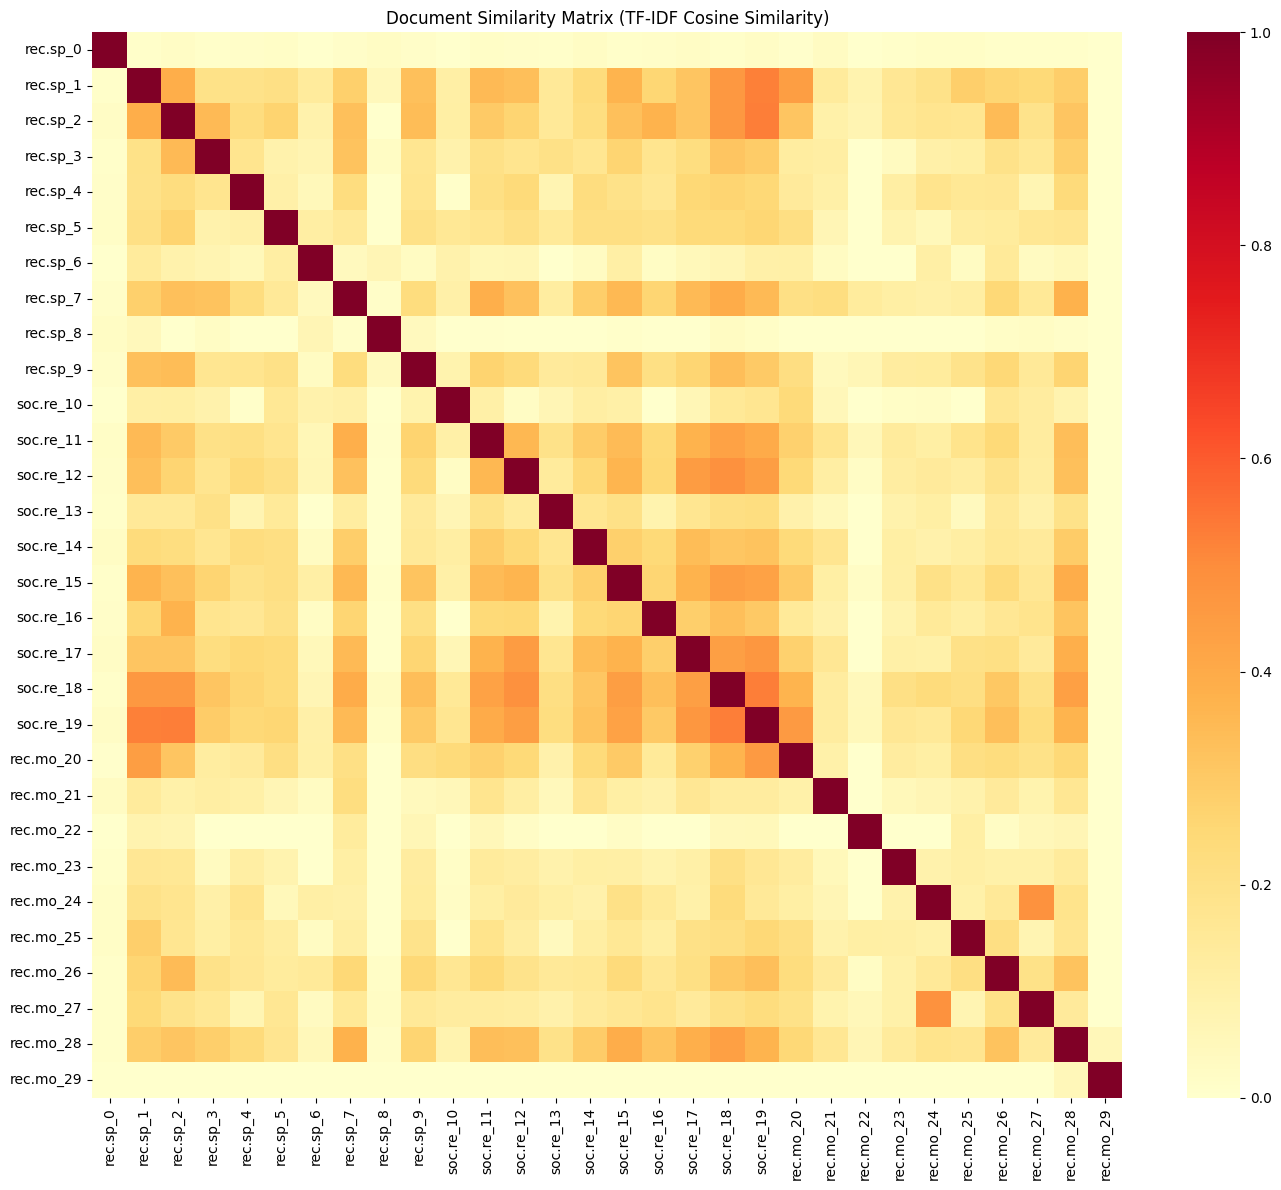

In [57]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Create text_clean column
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)   # keep letters and spaces only
    text = re.sub(r'\s+', ' ', text).strip()   # remove extra spaces
    return text

df['text_clean'] = df['text'].fillna("").apply(clean_text)

# 2. Pick 3 valid categories automatically
my_categories = df['label_text'].value_counts().head(3).index.tolist()
print("Using categories:", my_categories)

# 3. Filter dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()

# 4. Sample up to 10 documents from each category
sampled_dfs = []
for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category]

    if len(cat_df) == 0:
        continue

    sampled_dfs.append(cat_df.sample(n=min(10, len(cat_df)), random_state=42))

# 5. Combine sampled docs
df_sampled = pd.concat(sampled_dfs, ignore_index=True)

# 6. Create TF-IDF matrix
tfidf_sampled = TfidfVectorizer(max_features=500).fit_transform(df_sampled['text_clean'])

# 7. Compute cosine similarity
similarity_sampled = cosine_similarity(tfidf_sampled)

# 8. Labels
labels = [f"{cat[:6]}_{i}" for i, cat in enumerate(df_sampled['label_text'])]

# 9. Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    similarity_sampled,
    xticklabels=labels,
    yticklabels=labels,
    cmap="YlOrRd",
    annot=False
)

plt.title("Document Similarity Matrix (TF-IDF Cosine Similarity)")
plt.tight_layout()
plt.savefig("document_similarity_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### Written Question G.1 (Personal Interpretation)

Analyze the similarity heatmap:

1. **Do documents from the same category cluster together?** (i.e., do you see bright squares along the diagonal for each category group?)
2. **Which pair of categories is MOST similar to each other?** Which is LEAST similar?
3. **Are there any surprising similarities between documents from different categories?** If yes, what might explain this?

**YOUR ANSWER:**

1. Clustering observation: ...

2. Most/Least similar category pairs: ...

3. Surprising similarities: ...

---

## Summary - Part 1

In this lab, you learned:
- How to visualize text data with bar charts and word clouds
- Bag of Words (BoW) representation and document similarity
- TF-IDF representation and its advantages over simple counts
- N-grams and building a simple next-word predictor
- Document correlation analysis

---

## Submission Checklist - Part 1

- [ ] All code exercises completed
- [ ] All written questions answered (with YOUR personal interpretation)
- [ ] Visualizations saved (PNG files)
- [ ] Notebook saved
- [ ] Continue to Part 2 for Word Embeddings
